In [1]:
# ============================================================
# DATA INTEGRATION
# Enterprise HR AI Platform
# ============================================================

import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# PROJECT PATH SETUP
# ============================================================

CURRENT_DIR = Path.cwd()

PROJECT_ROOT = CURRENT_DIR.parent

FEATURE_ENGINEERED_PATH = PROJECT_ROOT / "data" / "feature_engineered"

INTEGRATED_DATA_PATH = PROJECT_ROOT / "data" / "integrated"

INTEGRATED_DATA_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print("Current Directory:")
print(CURRENT_DIR)

print("\nProject Root:")
print(PROJECT_ROOT)

print("\nFeature Engineered Data Path:")
print(FEATURE_ENGINEERED_PATH)

print("\nFeature Engineered Data Exists:")
print(FEATURE_ENGINEERED_PATH.exists())

print("\nIntegrated Data Path:")
print(INTEGRATED_DATA_PATH)

Current Directory:
C:\Users\Shubham\Desktop\enterprise_hr_ai\notebooks

Project Root:
C:\Users\Shubham\Desktop\enterprise_hr_ai

Feature Engineered Data Path:
C:\Users\Shubham\Desktop\enterprise_hr_ai\data\feature_engineered

Feature Engineered Data Exists:
True

Integrated Data Path:
C:\Users\Shubham\Desktop\enterprise_hr_ai\data\integrated


In [3]:
# ============================================================
# LOAD FEATURE ENGINEERED DATASETS
# ============================================================

dataset_files = {
    "employee": "employee_features.csv",
    "performance": "performance_features.csv",
    "occupational": "occupational_features.csv",
    "essential_skills": "essential_skills_features.csv",
    "software_skills": "software_skills_features.csv",
    "occupation_intelligence": "occupation_intelligence.csv"
}

integrated_source_data = {}

for name, filename in dataset_files.items():
    
    file_path = FEATURE_ENGINEERED_PATH / filename
    
    try:
        integrated_source_data[name] = pd.read_csv(file_path)
        
        print(
            f"✓ Loaded {name}: "
            f"{integrated_source_data[name].shape}"
        )
        
    except FileNotFoundError:
        print(f"✗ File not found: {filename}")

✓ Loaded employee: (1470, 47)
✓ Loaded performance: (5000, 19)
✓ Loaded occupational: (1016, 7)
✓ Loaded essential_skills: (18200, 18)
✓ Loaded software_skills: (31821, 13)
✓ Loaded occupation_intelligence: (1016, 17)


In [4]:
# ============================================================
# CREATE WORKING DATAFRAMES
# ============================================================

employee_df = integrated_source_data["employee"].copy()

performance_df = integrated_source_data["performance"].copy()

occupational_df = integrated_source_data["occupational"].copy()

essential_skills_df = integrated_source_data["essential_skills"].copy()

software_skills_df = integrated_source_data["software_skills"].copy()

occupation_intelligence_df = integrated_source_data[
    "occupation_intelligence"
].copy()

print("Working dataframes created successfully.")

Working dataframes created successfully.


In [5]:
# ============================================================
# DATASET INTEGRATION OVERVIEW
# ============================================================

integration_overview = pd.DataFrame([
    {
        "Dataset": "Employee Features",
        "Rows": employee_df.shape[0],
        "Columns": employee_df.shape[1],
        "Primary Integration Key": "Department"
    },
    {
        "Dataset": "Performance Features",
        "Rows": performance_df.shape[0],
        "Columns": performance_df.shape[1],
        "Primary Integration Key": "Department"
    },
    {
        "Dataset": "Occupational Features",
        "Rows": occupational_df.shape[0],
        "Columns": occupational_df.shape[1],
        "Primary Integration Key": "O*NET-SOC Code"
    },
    {
        "Dataset": "Essential Skills Features",
        "Rows": essential_skills_df.shape[0],
        "Columns": essential_skills_df.shape[1],
        "Primary Integration Key": "O*NET-SOC Code"
    },
    {
        "Dataset": "Software Skills Features",
        "Rows": software_skills_df.shape[0],
        "Columns": software_skills_df.shape[1],
        "Primary Integration Key": "O*NET-SOC Code"
    },
    {
        "Dataset": "Occupation Intelligence",
        "Rows": occupation_intelligence_df.shape[0],
        "Columns": occupation_intelligence_df.shape[1],
        "Primary Integration Key": "O*NET-SOC Code"
    }
])

print("DATASET INTEGRATION OVERVIEW")
print("=" * 80)

display(integration_overview)

DATASET INTEGRATION OVERVIEW


,Dataset,Rows,Columns,Primary Integration Key
0,Employee Features,1470,47,Department
1,Performance Features,5000,19,Department
2,Occupational Features,1016,7,O*NET-SOC Code
3,Essential Skills Features,18200,18,O*NET-SOC Code
4,Software Skills Features,31821,13,O*NET-SOC Code
5,Occupation Intelligence,1016,17,O*NET-SOC Code


In [6]:
# ============================================================
# INSPECT POTENTIAL INTEGRATION KEYS
# ============================================================

print("EMPLOYEE DATASET COLUMNS")
print("-" * 60)
print(employee_df.columns.tolist())

print("\nPERFORMANCE DATASET COLUMNS")
print("-" * 60)
print(performance_df.columns.tolist())

print("\nOCCUPATION INTELLIGENCE COLUMNS")
print("-" * 60)
print(occupation_intelligence_df.columns.tolist())

EMPLOYEE DATASET COLUMNS
------------------------------------------------------------
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'AgeGroup', 'IncomeCategory', 'ExperienceGroup', 'CompanyTenureGroup', 'OverallSatisfactionScore', 'SatisfactionCategory', 'OverTimeRisk', 'LongCommuteRisk', 'LowIncomeRisk', 'FrequentJobChangeRisk', 'AttritionRiskScore', 'AttritionRiskCategory']

PERFORMANCE DATASET COLUMNS
-------------------

In [7]:
# ============================================================
# COMPARE DEPARTMENT VALUES
# ============================================================

employee_departments = sorted(
    employee_df["Department"]
    .dropna()
    .astype(str)
    .unique()
)

performance_departments = sorted(
    performance_df["Department"]
    .dropna()
    .astype(str)
    .unique()
)

print("EMPLOYEE DATASET DEPARTMENTS")
print(employee_departments)

print("\nPERFORMANCE DATASET DEPARTMENTS")
print(performance_departments)

common_departments = sorted(
    set(employee_departments)
    .intersection(set(performance_departments))
)

print("\nCOMMON DEPARTMENTS")
print(common_departments)

print(
    f"\nNumber of common departments: "
    f"{len(common_departments)}"
)

EMPLOYEE DATASET DEPARTMENTS
['Human Resources', 'Research & Development', 'Sales']

PERFORMANCE DATASET DEPARTMENTS
['Finance', 'HR', 'IT', 'Marketing', 'Sales']

COMMON DEPARTMENTS
['Sales']

Number of common departments: 1


In [8]:
# ============================================================
# STANDARDIZE DEPARTMENT NAMES
# ============================================================

def standardize_department_name(value):
    
    if pd.isna(value):
        return np.nan
    
    return (
        str(value)
        .strip()
        .replace("&", "and")
        .lower()
    )


employee_df["Department_Standardized"] = (
    employee_df["Department"]
    .apply(standardize_department_name)
)

performance_df["Department_Standardized"] = (
    performance_df["Department"]
    .apply(standardize_department_name)
)

print("Department names standardized successfully.")

Department names standardized successfully.


In [9]:
# ============================================================
# VERIFY DEPARTMENT INTEGRATION KEYS
# ============================================================

employee_department_keys = sorted(
    employee_df["Department_Standardized"]
    .dropna()
    .unique()
)

performance_department_keys = sorted(
    performance_df["Department_Standardized"]
    .dropna()
    .unique()
)

common_standardized_departments = sorted(
    set(employee_department_keys)
    .intersection(set(performance_department_keys))
)

print("EMPLOYEE DEPARTMENT KEYS")
print(employee_department_keys)

print("\nPERFORMANCE DEPARTMENT KEYS")
print(performance_department_keys)

print("\nCOMMON STANDARDIZED KEYS")
print(common_standardized_departments)

print(
    f"\nSuccessfully matched departments: "
    f"{len(common_standardized_departments)}"
)

EMPLOYEE DEPARTMENT KEYS
['human resources', 'research and development', 'sales']

PERFORMANCE DEPARTMENT KEYS
['finance', 'hr', 'it', 'marketing', 'sales']

COMMON STANDARDIZED KEYS
['sales']

Successfully matched departments: 1


In [10]:
# ============================================================
# EMPLOYEE DEPARTMENT-LEVEL METRICS
# ============================================================

employee_department_summary = (
    employee_df
    .groupby(
        "Department_Standardized",
        as_index=False
    )
    .agg(
        Department=("Department", "first"),
        
        Total_Employees=(
            "EmployeeNumber",
            "count"
        ),
        
        Employees_Left=(
            "Attrition",
            lambda x: (x == "Yes").sum()
        ),
        
        Average_Age=(
            "Age",
            "mean"
        ),
        
        Average_Monthly_Income=(
            "MonthlyIncome",
            "mean"
        ),
        
        Average_Satisfaction=(
            "OverallSatisfactionScore",
            "mean"
        ),
        
        Average_Attrition_Risk=(
            "AttritionRiskScore",
            "mean"
        )
    )
)

employee_department_summary["Attrition_Rate"] = (
    employee_department_summary["Employees_Left"]
    /
    employee_department_summary["Total_Employees"]
    * 100
).round(2)

employee_department_summary[
    "Average_Age"
] = employee_department_summary[
    "Average_Age"
].round(2)

employee_department_summary[
    "Average_Monthly_Income"
] = employee_department_summary[
    "Average_Monthly_Income"
].round(2)

employee_department_summary[
    "Average_Satisfaction"
] = employee_department_summary[
    "Average_Satisfaction"
].round(2)

employee_department_summary[
    "Average_Attrition_Risk"
] = employee_department_summary[
    "Average_Attrition_Risk"
].round(2)

print("EMPLOYEE DEPARTMENT SUMMARY")
print("=" * 80)

display(employee_department_summary)

EMPLOYEE DEPARTMENT SUMMARY


,Department_Standardized,Department,Total_Employees,Employees_Left,Average_Age,Average_Monthly_Income,Average_Satisfaction,Average_Attrition_Risk,Attrition_Rate
0,human resources,Human Resources,63,12,37.81,6654.51,2.77,2.21,19.05
1,research and development,Research & Development,961,133,37.04,6281.25,2.73,2.15,13.84
2,sales,Sales,446,92,36.54,6959.17,2.74,1.97,20.63


In [11]:
# ============================================================
# PERFORMANCE DEPARTMENT-LEVEL METRICS
# ============================================================

performance_department_summary = (
    performance_df
    .groupby(
        "Department_Standardized",
        as_index=False
    )
    .agg(
        Performance_Department=(
            "Department",
            "first"
        ),
        
        Performance_Records=(
            "Department",
            "count"
        ),
        
        Average_Performance_Score=(
            "Performance Score",
            "mean"
        ),
        
        Average_KPI_Score=(
            "KPI Score",
            "mean"
        ),
        
        Average_Attendance=(
            "Attendance (%)",
            "mean"
        ),
        
        Average_Peer_Rating=(
            "Peer Rating",
            "mean"
        ),
        
        Average_Task_Completion=(
            "Task Completion (%)",
            "mean"
        ),
        
        Average_Work_Hours=(
            "Work Hours Logged",
            "mean"
        ),
        
        Average_Training_Hours=(
            "Training Hours",
            "mean"
        )
    )
)

numeric_columns = [
    "Average_Performance_Score",
    "Average_KPI_Score",
    "Average_Attendance",
    "Average_Peer_Rating",
    "Average_Task_Completion",
    "Average_Work_Hours",
    "Average_Training_Hours"
]

performance_department_summary[
    numeric_columns
] = performance_department_summary[
    numeric_columns
].round(2)

print("PERFORMANCE DEPARTMENT SUMMARY")
print("=" * 80)

display(performance_department_summary)

PERFORMANCE DEPARTMENT SUMMARY


,Department_Standardized,Performance_Department,Performance_Records,Average_Performance_Score,Average_KPI_Score,Average_Attendance,Average_Peer_Rating,Average_Task_Completion,Average_Work_Hours,Average_Training_Hours
0,finance,Finance,1016,75.16,77.39,87.55,4.01,84.94,45.02,15.47
1,hr,HR,1010,75.83,77.66,87.27,4.00,85.40,45.07,14.59
2,it,IT,974,74.68,77.45,87.66,3.98,84.81,44.91,14.64
3,marketing,Marketing,965,73.86,76.90,87.26,4.03,84.96,44.83,15.05
4,sales,Sales,1035,74.34,77.50,87.58,3.99,84.78,44.82,14.63


In [12]:
# ============================================================
# PROMOTION ELIGIBILITY BY DEPARTMENT
# ============================================================

promotion_eligibility_summary = (
    performance_df
    .groupby(
        "Department_Standardized"
    )["Promotion Eligibility"]
    .apply(
        lambda x: (
            x.astype(str)
            .str.strip()
            .str.lower()
            .isin(["yes", "eligible", "true"])
            .mean()
            * 100
        )
    )
    .reset_index(
        name="Promotion_Eligibility_Rate"
    )
)

promotion_eligibility_summary[
    "Promotion_Eligibility_Rate"
] = promotion_eligibility_summary[
    "Promotion_Eligibility_Rate"
].round(2)

display(promotion_eligibility_summary)

,Department_Standardized,Promotion_Eligibility_Rate
0,finance,14.17
1,hr,15.25
2,it,13.24
3,marketing,13.47
4,sales,13.33


In [13]:
# ============================================================
# MERGE PERFORMANCE METRICS
# ============================================================

performance_department_summary = (
    performance_department_summary
    .merge(
        promotion_eligibility_summary,
        on="Department_Standardized",
        how="left"
    )
)

print("Performance metrics merged successfully.")

display(performance_department_summary)

Performance metrics merged successfully.


,Department_Standardized,Performance_Department,Performance_Records,Average_Performance_Score,Average_KPI_Score,Average_Attendance,Average_Peer_Rating,Average_Task_Completion,Average_Work_Hours,Average_Training_Hours,Promotion_Eligibility_Rate
0,finance,Finance,1016,75.16,77.39,87.55,4.01,84.94,45.02,15.47,14.17
1,hr,HR,1010,75.83,77.66,87.27,4.00,85.40,45.07,14.59,15.25
2,it,IT,974,74.68,77.45,87.66,3.98,84.81,44.91,14.64,13.24
3,marketing,Marketing,965,73.86,76.90,87.26,4.03,84.96,44.83,15.05,13.47
4,sales,Sales,1035,74.34,77.50,87.58,3.99,84.78,44.82,14.63,13.33


In [14]:
# ============================================================
# CREATE DEPARTMENT INTELLIGENCE DATASET
# ============================================================

department_intelligence = (
    employee_department_summary
    .merge(
        performance_department_summary,
        on="Department_Standardized",
        how="inner"
    )
)

department_intelligence = department_intelligence.drop(
    columns=["Performance_Department"]
)

print("DEPARTMENT INTELLIGENCE DATASET")
print("=" * 80)

print(
    f"Shape: {department_intelligence.shape}"
)

display(department_intelligence)

DEPARTMENT INTELLIGENCE DATASET
Shape: (1, 18)


,Department_Standardized,Department,Total_Employees,Employees_Left,Average_Age,Average_Monthly_Income,Average_Satisfaction,Average_Attrition_Risk,Attrition_Rate,Performance_Records,Average_Performance_Score,Average_KPI_Score,Average_Attendance,Average_Peer_Rating,Average_Task_Completion,Average_Work_Hours,Average_Training_Hours,Promotion_Eligibility_Rate
0,sales,Sales,446,92,36.54,6959.17,2.74,1.97,20.63,1035,74.34,77.5,87.58,3.99,84.78,44.82,14.63,13.33


In [15]:
# ============================================================
# VALIDATE DEPARTMENT INTEGRATION
# ============================================================

print("DEPARTMENT INTEGRATION VALIDATION")
print("=" * 80)

print(
    f"Employee Departments: "
    f"{employee_department_summary.shape[0]}"
)

print(
    f"Performance Departments: "
    f"{performance_department_summary.shape[0]}"
)

print(
    f"Integrated Departments: "
    f"{department_intelligence.shape[0]}"
)

print(
    "\nMissing Values in Integrated Dataset:"
)

display(
    department_intelligence
    .isnull()
    .sum()
    .to_frame(
        name="Missing Values"
    )
)

DEPARTMENT INTEGRATION VALIDATION
Employee Departments: 3
Performance Departments: 5
Integrated Departments: 1

Missing Values in Integrated Dataset:


,Missing Values
Department_Standardized,0
Department,0
Total_Employees,0
Employees_Left,0
Average_Age,0
Average_Monthly_Income,0
Average_Satisfaction,0
Average_Attrition_Risk,0
Attrition_Rate,0
Performance_Records,0


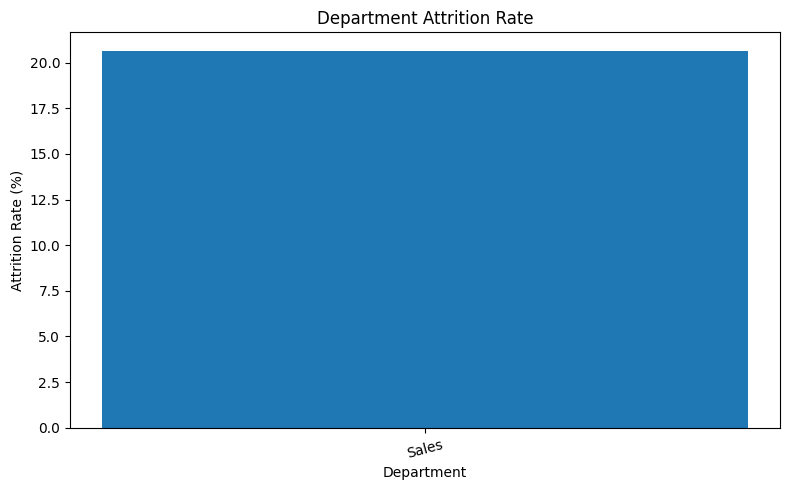

In [16]:
# ============================================================
# DEPARTMENT ATTRITION ANALYSIS
# ============================================================

department_intelligence_sorted = (
    department_intelligence
    .sort_values(
        by="Attrition_Rate",
        ascending=False
    )
)

plt.figure(figsize=(8, 5))

plt.bar(
    department_intelligence_sorted["Department"],
    department_intelligence_sorted["Attrition_Rate"]
)

plt.title("Department Attrition Rate")

plt.xlabel("Department")

plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

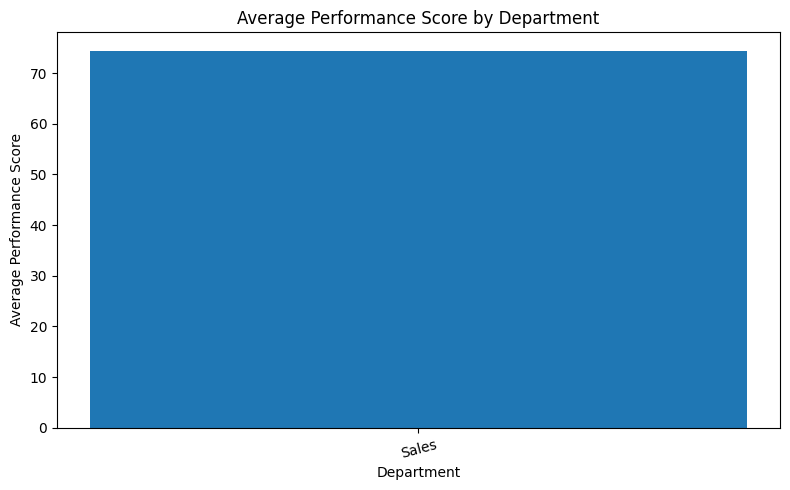

In [17]:
# ============================================================
# DEPARTMENT PERFORMANCE ANALYSIS
# ============================================================

department_intelligence_sorted = (
    department_intelligence
    .sort_values(
        by="Average_Performance_Score",
        ascending=False
    )
)

plt.figure(figsize=(8, 5))

plt.bar(
    department_intelligence_sorted["Department"],
    department_intelligence_sorted[
        "Average_Performance_Score"
    ]
)

plt.title("Average Performance Score by Department")

plt.xlabel("Department")

plt.ylabel("Average Performance Score")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

In [18]:
# ============================================================
# ATTRITION VS PERFORMANCE COMPARISON
# ============================================================

comparison_df = department_intelligence[
    [
        "Department",
        "Attrition_Rate",
        "Average_Performance_Score",
        "Average_KPI_Score",
        "Average_Attendance",
        "Average_Satisfaction",
        "Average_Attrition_Risk"
    ]
].copy()

comparison_df = comparison_df.sort_values(
    by="Attrition_Rate",
    ascending=False
)

print("ATTRITION AND PERFORMANCE COMPARISON")
print("=" * 80)

display(comparison_df)

ATTRITION AND PERFORMANCE COMPARISON


,Department,Attrition_Rate,Average_Performance_Score,Average_KPI_Score,Average_Attendance,Average_Satisfaction,Average_Attrition_Risk
0,Sales,20.63,74.34,77.5,87.58,2.74,1.97


In [19]:
# ============================================================
# OCCUPATION INTELLIGENCE VALIDATION
# ============================================================

print("OCCUPATION INTELLIGENCE VALIDATION")
print("=" * 80)

print(
    f"Total Occupations: "
    f"{occupation_intelligence_df.shape[0]}"
)

print(
    f"Total Features: "
    f"{occupation_intelligence_df.shape[1]}"
)

print(
    f"Duplicate O*NET-SOC Codes: "
    f"{occupation_intelligence_df['O*NET-SOC Code'].duplicated().sum()}"
)

print(
    f"Missing Values: "
    f"{occupation_intelligence_df.isnull().sum().sum()}"
)

display(
    occupation_intelligence_df.head()
)

OCCUPATION INTELLIGENCE VALIDATION
Total Occupations: 1016
Total Features: 17
Duplicate O*NET-SOC Codes: 0
Missing Values: 995


,O*NET-SOC Code,Title,Description,TitleLength,TitleWordCount,DescriptionLength,DescriptionWordCount,TotalSkillRecords,UniqueSkills,AverageSkillValue,MaximumSkillValue,MinimumSkillValue,TotalSoftwareSkillRecords,UniqueSoftwareSkills,HotTechnologies,InDemandTechnologies,AverageTechnologyDemandScore
0,11-1011.00,Chief Executives,Determine and formulate policies and provide o...,16,2,340,50,20.0,10.0,3.88,5.25,0.75,48.0,23.0,16.0,4.0,0.42
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh...",29,3,170,20,20.0,10.0,3.67,4.25,1.88,21.0,16.0,14.0,4.0,0.86
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ...",31,4,530,70,20.0,10.0,3.42,4.12,0.62,141.0,53.0,49.0,3.0,0.37
3,11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes...",11,1,137,21,NaN,NaN,NaN,NaN,NaN,32.0,16.0,11.0,0.0,0.34
4,11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici...",35,4,275,42,20.0,10.0,3.45,4.12,0.50,72.0,27.0,27.0,3.0,0.42


In [20]:
# ============================================================
# TOP OCCUPATION SKILL INTELLIGENCE
# ============================================================

print("OCCUPATION INTELLIGENCE OVERVIEW")
print("=" * 80)

display(
    occupation_intelligence_df.head(10)
)

OCCUPATION INTELLIGENCE OVERVIEW


,O*NET-SOC Code,Title,Description,TitleLength,TitleWordCount,DescriptionLength,DescriptionWordCount,TotalSkillRecords,UniqueSkills,AverageSkillValue,MaximumSkillValue,MinimumSkillValue,TotalSoftwareSkillRecords,UniqueSoftwareSkills,HotTechnologies,InDemandTechnologies,AverageTechnologyDemandScore
0,11-1011.00,Chief Executives,Determine and formulate policies and provide o...,16,2,340,50,20.0,10.0,3.88,5.25,0.75,48.0,23.0,16.0,4.0,0.42
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh...",29,3,170,20,20.0,10.0,3.67,4.25,1.88,21.0,16.0,14.0,4.0,0.86
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ...",31,4,530,70,20.0,10.0,3.42,4.12,0.62,141.0,53.0,49.0,3.0,0.37
3,11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes...",11,1,137,21,NaN,NaN,NaN,NaN,NaN,32.0,16.0,11.0,0.0,0.34
4,11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici...",35,4,275,42,20.0,10.0,3.45,4.12,0.50,72.0,27.0,27.0,3.0,0.42
5,11-2021.00,Marketing Managers,"Plan, direct, or coordinate marketing policies...",18,2,438,66,20.0,10.0,3.56,4.12,1.25,154.0,46.0,68.0,6.0,0.48
6,11-2022.00,Sales Managers,"Plan, direct, or coordinate the actual distrib...",14,2,387,53,20.0,10.0,3.53,4.62,0.62,103.0,40.0,39.0,5.0,0.43
7,11-2032.00,Public Relations Managers,"Plan, direct, or coordinate activities designe...",25,3,153,23,20.0,10.0,3.34,4.25,0.25,65.0,24.0,29.0,4.0,0.51
8,11-2033.00,Fundraising Managers,"Plan, direct, or coordinate activities to soli...",20,2,117,16,20.0,10.0,3.31,4.12,0.25,60.0,23.0,24.0,7.0,0.52
9,11-3012.00,Administrative Services Managers,"Plan, direct, or coordinate one or more admini...",32,3,181,25,20.0,10.0,3.20,4.00,0.00,56.0,30.0,22.0,5.0,0.48


In [21]:
# ============================================================
# FINAL DATA INTEGRATION SUMMARY
# ============================================================

integration_summary = pd.DataFrame([
    
    {
        "Integrated Dataset": "Department Intelligence",
        "Rows": department_intelligence.shape[0],
        "Columns": department_intelligence.shape[1],
        "Integration Method": "Department-Level Aggregation"
    },
    
    {
        "Integrated Dataset": "Occupation Intelligence",
        "Rows": occupation_intelligence_df.shape[0],
        "Columns": occupation_intelligence_df.shape[1],
        "Integration Method": "O*NET-SOC Code Integration"
    },
    
    {
        "Integrated Dataset": "Employee Features",
        "Rows": employee_df.shape[0],
        "Columns": employee_df.shape[1],
        "Integration Method": "Standalone Workforce Intelligence"
    },
    
    {
        "Integrated Dataset": "Performance Features",
        "Rows": performance_df.shape[0],
        "Columns": performance_df.shape[1],
        "Integration Method": "Standalone Performance Intelligence"
    }
])

print("FINAL DATA INTEGRATION SUMMARY")
print("=" * 100)

display(integration_summary)

FINAL DATA INTEGRATION SUMMARY


,Integrated Dataset,Rows,Columns,Integration Method
0,Department Intelligence,1,18,Department-Level Aggregation
1,Occupation Intelligence,1016,17,O*NET-SOC Code Integration
2,Employee Features,1470,48,Standalone Workforce Intelligence
3,Performance Features,5000,20,Standalone Performance Intelligence


In [22]:
# ============================================================
# SAVE INTEGRATED DATASETS
# ============================================================

datasets_to_save = {
    "department_intelligence.csv": department_intelligence,
    "occupation_intelligence_integrated.csv": occupation_intelligence_df,
    "integration_summary.csv": integration_summary
}

for filename, dataframe in datasets_to_save.items():
    
    save_path = INTEGRATED_DATA_PATH / filename
    
    dataframe.to_csv(
        save_path,
        index=False
    )
    
    print(
        f"✓ Saved {filename} "
        f"{dataframe.shape}"
    )

print("\nIntegrated datasets saved successfully.")

print("\nLocation:")
print(INTEGRATED_DATA_PATH)

✓ Saved department_intelligence.csv (1, 18)
✓ Saved occupation_intelligence_integrated.csv (1016, 17)
✓ Saved integration_summary.csv (4, 4)

Integrated datasets saved successfully.

Location:
C:\Users\Shubham\Desktop\enterprise_hr_ai\data\integrated


In [23]:
# ============================================================
# VERIFY SAVED INTEGRATED DATASETS
# ============================================================

print("INTEGRATED DATA FILES")
print("=" * 70)

for file in sorted(
    INTEGRATED_DATA_PATH.glob("*.csv")
):
    
    file_size_kb = (
        file.stat().st_size / 1024
    )
    
    print(
        f"✓ {file.name} "
        f"({file_size_kb:.2f} KB)"
    )

INTEGRATED DATA FILES
✓ department_intelligence.csv (0.45 KB)
✓ integration_summary.csv (0.29 KB)
✓ occupation_intelligence_integrated.csv (316.57 KB)


In [24]:
# ============================================================
# DATA INTEGRATION COMPLETION STATUS
# ============================================================

print("DATA INTEGRATION COMPLETED SUCCESSFULLY")
print("=" * 80)

print(
    "\n✓ Employee workforce data integrated "
    "at department level"
)

print(
    "✓ Performance data integrated "
    "at department level"
)

print(
    "✓ Department intelligence dataset created"
)

print(
    "✓ Occupation and skills intelligence validated"
)

print(
    "✓ Integrated datasets saved permanently"
)

print("\nREADY FOR NEXT PHASE")
print("Machine Learning / Advanced HR Analytics")

DATA INTEGRATION COMPLETED SUCCESSFULLY

✓ Employee workforce data integrated at department level
✓ Performance data integrated at department level
✓ Department intelligence dataset created
✓ Occupation and skills intelligence validated
✓ Integrated datasets saved permanently

READY FOR NEXT PHASE
Machine Learning / Advanced HR Analytics
